# Experiment 4 - A predictive memory model, and the OOM frontier

Decode at this model size is launch-bound, so this study reports memory. Two claims:

1. Peak memory is linear in `batch * seq_len`, with a slope derivable from the architecture.
2. INT8 moves the OOM frontier outward (H3).

The model is fit on `exp3_precision_sweep.csv` (40 cells). `oom_frontier.json`
(5 budgets x 5 cells x 2 dtypes) is held out and used only to test it.

Budgets are enforced with `set_per_process_memory_fraction`. Without the cap the Windows driver
spills to host RAM rather than raising, and no OOM is reachable on this machine.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def results_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'experiments' / 'results').exists():
            return base / 'experiments' / 'results'
    raise FileNotFoundError('experiments/results not found from ' + str(Path.cwd()))


RESULTS = results_dir()
DTYPES = ('fp16', 'int8')

sweep = pd.read_csv(RESULTS / 'exp3_precision_sweep.csv')
sweep = sweep[sweep.status.eq('ok')].copy()
sweep['tokens'] = sweep.seq_len * sweep.batch

frontier = pd.json_normalize(json.load(open(RESULTS / 'oom_frontier.json')))
frontier['tokens'] = frontier.seq_len * frontier.batch
frontier['cell'] = frontier.seq_len.astype(str) + 'x' + frontier.batch.astype(str)

print(f'fit set : {len(sweep)} cells, {sweep.tokens.min():,}-{sweep.tokens.max():,} tokens')
print(f'held out: {len(frontier)} (budget, cell) rows x {len(DTYPES)} dtypes, '
      f'up to {frontier.tokens.max():,} tokens')

fit set : 40 cells, 512-262,144 tokens
held out: 25 (budget, cell) rows x 2 dtypes, up to 524,288 tokens


## 1. The model

Peak memory should be linear in the number of resident tokens, and the KV term of that slope is
derivable before anything is run:

    cache KB/token = 2 * n_layers * n_heads * head_dim * bytes / 1024

with `bytes` = 2 for FP16 and `1 + 2/head_dim` for INT8 (one byte plus an FP16 scale per token per
head). The remainder is per-token activation cost, which has to be measured.

In [2]:
CFG = dict(n_layers=8, n_heads=8, head_dim=64)          # study model
BYTES = {'fp16': 2.0, 'int8': 1.0 + 2.0 / CFG['head_dim']}

fits = {}
for dt in DTYPES:
    s = sweep[sweep.cache_type == f'paged_{dt}']
    slope, icept = np.polyfit(s.tokens, s.peak_memory_mb, 1)
    pred = slope * s.tokens + icept
    r2 = 1 - ((s.peak_memory_mb - pred) ** 2).sum() / \
        ((s.peak_memory_mb - s.peak_memory_mb.mean()) ** 2).sum()
    fits[dt] = (slope, icept)

    measured_cache = np.polyfit(s.tokens, s.cache_memory_mb, 1)[0] * 1024
    derived_cache = 2 * CFG['n_layers'] * CFG['n_heads'] * CFG['head_dim'] * BYTES[dt] / 1024
    print(f'{dt}  peak = {slope * 1024:5.2f} KB/token * (batch*seq) + {icept:.0f} MB   R2 {r2:.5f}')
    print(f'      cache slope {measured_cache:6.3f} measured vs {derived_cache:6.3f} derived'
          f'  ({100 * (measured_cache / derived_cache - 1):+.2f}%)')

fp16  peak = 27.15 KB/token * (batch*seq) + 168 MB   R2 0.99997
      cache slope 16.109 measured vs 16.000 derived  (+0.68%)
int8  peak = 19.93 KB/token * (batch*seq) + 164 MB   R2 0.99999
      cache slope  8.306 measured vs  8.250 derived  (+0.68%)


In [3]:
# batch and seq_len enter only through their product: equal-token cells, different shapes.
for dt in DTYPES:
    ok = frontier[frontier[f'{dt}.status'].eq('ok')].drop_duplicates('cell').set_index('cell')
    for a, b in [('8192x32', '16384x16'), ('8192x64', '16384x32')]:
        if a in ok.index and b in ok.index:
            pa, pb = ok.loc[a, f'{dt}.peak_mb'], ok.loc[b, f'{dt}.peak_mb']
            print(f'{dt}  {a} {pa:8.1f} MB   {b} {pb:8.1f} MB   differ by '
                  f'{200 * abs(pa - pb) / (pa + pb):.3f}%')

fp16  8192x32   7086.5 MB   16384x16   7090.6 MB   differ by 0.058%
int8  8192x32   5246.6 MB   16384x16   5255.5 MB   differ by 0.169%
int8  8192x64  10328.9 MB   16384x32  10332.8 MB   differ by 0.038%


## 2. Held-out prediction

The frontier ladder reaches 524,288 resident tokens against a fit range ending at 262,144, so this
is extrapolation.

In [4]:
rows = []
for dt in DTYPES:
    slope, icept = fits[dt]
    for r in frontier[frontier[f'{dt}.status'].eq('ok')].drop_duplicates('cell').itertuples():
        meas = frontier.loc[r.Index, f'{dt}.peak_mb']
        pred = slope * r.tokens + icept
        rows.append(dict(dtype=dt, cell=r.cell, tokens=r.tokens, measured_mb=meas,
                         predicted_mb=round(pred, 1),
                         error_pct=round(100 * (pred - meas) / meas, 2),
                         cache_share=round(100 * frontier.loc[r.Index, f'{dt}.cache_mb'] / meas, 1)))

held = pd.DataFrame(rows).sort_values(['dtype', 'tokens'])
print(held.to_string(index=False))
print(f'\nerror {held.error_pct.min():+.2f}% to {held.error_pct.max():+.2f}%')

dtype     cell  tokens  measured_mb  predicted_mb  error_pct  cache_share
 fp16  8192x32  262144       7086.5        7119.1       0.46         57.9
 fp16 16384x16  262144       7090.6        7119.1       0.40         57.8
 fp16  8192x48  393216      10547.6       10594.6       0.45         58.4
 int8  8192x32  262144       5246.6        5264.9       0.35         40.3
 int8 16384x16  262144       5255.5        5264.9       0.18         40.2
 int8  8192x48  393216       7790.6        7815.3       0.32         40.7
 int8  8192x64  524288      10328.9       10365.8       0.36         41.0
 int8 16384x32  524288      10332.8       10365.8       0.32         40.9

error +0.18% to +0.46%


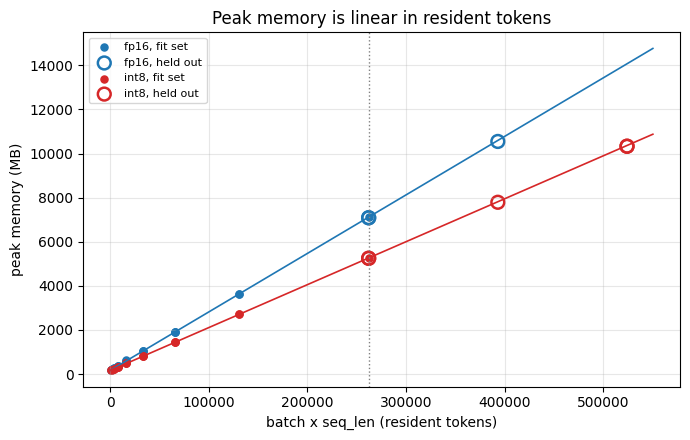

In [5]:
# Figure 1 - the fit, extrapolated through the held-out cells.
COL = {'fp16': '#1f77b4', 'int8': '#d62728'}
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.linspace(0, frontier.tokens.max() * 1.05, 100)

for dt in DTYPES:
    s = sweep[sweep.cache_type == f'paged_{dt}']
    slope, icept = fits[dt]
    ax.plot(x, slope * x + icept, color=COL[dt], lw=1.2)
    ax.scatter(s.tokens, s.peak_memory_mb, s=26, color=COL[dt], label=f'{dt}, fit set')
    h = held[held.dtype == dt]
    ax.scatter(h.tokens, h.measured_mb, s=85, facecolors='none', edgecolors=COL[dt],
               linewidths=1.8, label=f'{dt}, held out')

ax.axvline(sweep.tokens.max(), color='gray', ls=':', lw=1)
ax.set(xlabel='batch x seq_len (resident tokens)', ylabel='peak memory (MB)',
       title='Peak memory is linear in resident tokens')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Predicting the frontier

The useful form of the model is a decision made before the run: does this cell fit in this budget?
Each (budget, cell, dtype) trial is one binary prediction.

In [6]:
trials = []
for r in frontier.itertuples():
    for dt in DTYPES:
        slope, icept = fits[dt]
        pred_mb = slope * r.tokens + icept
        trials.append(dict(budget_gb=r.budget_gb, cell=r.cell, dtype=dt,
                           predicted_mb=round(pred_mb, 1),
                           predicted='ok' if pred_mb < r.budget_gb * 1024 else 'oom',
                           observed=frontier.loc[r.Index, f'{dt}.status'],
                           pct_of_budget=round(100 * pred_mb / (r.budget_gb * 1024), 1)))

trials = pd.DataFrame(trials)
correct = (trials.predicted == trials.observed).sum()
print(f'{correct}/{len(trials)} verdicts correct\n')
print(pd.crosstab(trials.predicted, trials.observed).to_string())

miss = trials[trials.predicted != trials.observed]
print('\nmiss:\n' + miss.to_string(index=False))
print('\nThe model predicts allocated bytes; the allocator needs reserved bytes. Predictions '
      'within a few percent of the cap are coin flips.')

49/50 verdicts correct

observed   ok  oom
predicted         
ok         30    1
oom         0   19

miss:
 budget_gb    cell dtype  predicted_mb predicted observed  pct_of_budget
       8.0 8192x48  int8        7815.3        ok      oom           95.4

The model predicts allocated bytes; the allocator needs reserved bytes. Predictions within a few percent of the cap are coin flips.


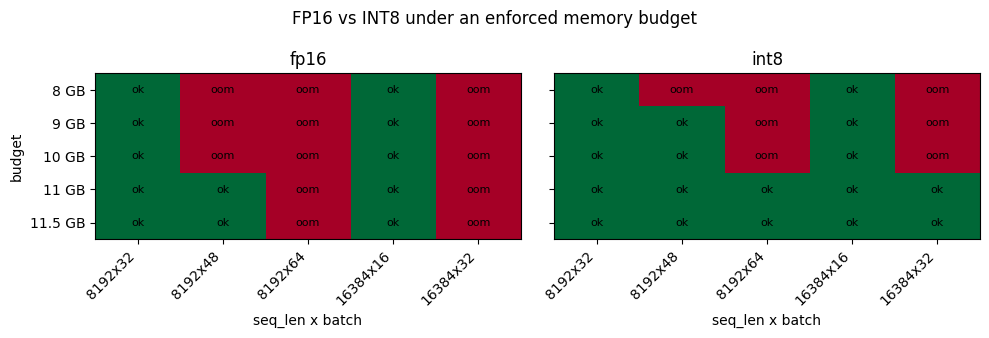

6 trials separate the dtypes (FP16 OOM, INT8 completes):
cell
16384x32    [11.0, 11.5]
8192x48      [9.0, 10.0]
8192x64     [11.0, 11.5]


In [7]:
# Figure 2 - what fits under an enforced budget.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
cells = list(dict.fromkeys(frontier.cell))

for ax, dt in zip(axes, DTYPES):
    g = frontier.pivot(index='budget_gb', columns='cell', values=f'{dt}.status')[cells]
    ax.imshow((g.values == 'ok').astype(float), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(cells)), cells, rotation=45, ha='right')
    ax.set_yticks(range(len(g.index)), [f'{b:g} GB' for b in g.index])
    ax.set(title=dt, xlabel='seq_len x batch')
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            ax.text(j, i, g.values[i, j], ha='center', va='center', fontsize=8)

axes[0].set_ylabel('budget')
fig.suptitle('FP16 vs INT8 under an enforced memory budget')
fig.tight_layout()
plt.show()

fr = frontier[frontier.verdict == 'FRONTIER']
print(f'{len(fr)} trials separate the dtypes (FP16 OOM, INT8 completes):')
print(fr.groupby('cell').budget_gb.apply(list).to_string())

## 4. Why the frontier does not move further

INT8 halves the cache, but not all of that saving reaches the peak.

In [8]:
both = frontier[frontier['fp16.status'].eq('ok') & frontier['int8.status'].eq('ok')] \
    .drop_duplicates('cell').copy()
both['cache_saved'] = both['fp16.cache_mb'] - both['int8.cache_mb']
both['peak_saved'] = both['fp16.peak_mb'] - both['int8.peak_mb']
both['delivered_pct'] = 100 * both.peak_saved / both.cache_saved
both['lost_kb_per_token'] = (both.cache_saved - both.peak_saved) * 1024 / both.tokens

print(both[['cell', 'cache_saved', 'peak_saved', 'delivered_pct',
            'lost_kb_per_token']].round(2).to_string(index=False))
print(f'\n{both.delivered_pct.mean():.1f}% of the cache saving reaches peak. The shortfall is '
      f'{both.lost_kb_per_token.mean():.2f} KB/token, constant across cells, so it grows with the '
      f'history - a dequantized FP16 temporary is the suspect. Not isolated yet.')
print(f'Cache is {100 * (both["fp16.cache_mb"] / both["fp16.peak_mb"]).mean():.0f}% of peak at '
      f'FP16 and {100 * (both["int8.cache_mb"] / both["int8.peak_mb"]).mean():.0f}% at INT8; '
      f'the rest is prefill activations, which quantizing the cache does nothing for.')

    cell  cache_saved  peak_saved  delivered_pct  lost_kb_per_token
 8192x32       1987.9      1839.9          92.55               0.58
16384x16       1985.9      1835.1          92.41               0.59
 8192x48       2981.8      2757.0          92.46               0.59

92.5% of the cache saving reaches peak. The shortfall is 0.58 KB/token, constant across cells, so it grows with the history - a dequantized FP16 temporary is the suspect. Not isolated yet.
Cache is 58% of peak at FP16 and 40% at INT8; the rest is prefill activations, which quantizing the cache does nothing for.


## 5. Summary

In [9]:
for dt in DTYPES:
    slope, icept = fits[dt]
    print(f'{dt}: peak_MB = {slope * 1024:.2f} * (batch*seq)/1024 + {icept:.0f}')
print(f'held out : {held.error_pct.min():+.2f}% to {held.error_pct.max():+.2f}% on '
      f'{len(held)} cells beyond the fit range')
print(f'verdicts : {correct}/{len(trials)}; the miss sits at {miss.pct_of_budget.iloc[0]:.0f}% '
      f'of budget')
print(f'H3       : supported under a budget - {len(fr)} trials where FP16 OOMs and INT8 completes')
print(f'cost     : {100 - both.delivered_pct.mean():.1f}% of the INT8 saving never reaches peak')

fp16: peak_MB = 27.15 * (batch*seq)/1024 + 168
int8: peak_MB = 19.93 * (batch*seq)/1024 + 164
held out : +0.18% to +0.46% on 8 cells beyond the fit range
verdicts : 49/50; the miss sits at 95% of budget
H3       : supported under a budget - 6 trials where FP16 OOMs and INT8 completes
cost     : 7.5% of the INT8 saving never reaches peak


## Caveats

- Peak is `max_memory_allocated`, not reserved; the model does not see allocator fragmentation. That
  is what the one wrong verdict is made of.
- One architecture (8L/512d/2048ff) and one `block_size` (16). Transfer across shapes is
  Experiment 5.
- The budget is a cap on the PyTorch allocator, not on the device. Results are stated in units of
  the budget, which is what makes them portable.
- `oom_frontier.json` records neither the GPU nor the commit. Fix before quoting these numbers.